# Descriptive Analysis: WritingPrompts (Raw Corpus)

**Dataset:** Fan, Lewis & Dauphin (2018). *Hierarchical Neural Story Generation.* ACL 2018.
HF mirror: `euclaise/writingprompts`

**Scope:** the raw corpus as released (train / validation / test) before the 200-prompt sample drawn in `data_generation/writingprompts_generation.ipynb`    
For the sampled subset + the four LLM generations see `descriptive_analysis_storytelling.ipynb`.

In [1]:
# Load libraries
import re
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

import warnings
warnings.filterwarnings('ignore')

# Plotting parameters
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 11})

FIG_DIR = pathlib.Path('../figures/data_description')
FIG_DIR.mkdir(parents=True, exist_ok=True)

/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/Masterthesis/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load & Prepare Data

Original release is pre-tokenized (`<newline>` markers, spaces before punctuation)

In [2]:
def detokenize(text):
    """Undo the pre-tokenization of the raw WritingPrompts files."""

    # Replace <newline> with actual newlines
    text = text.replace('<newline>', '\n')

    # Remove spaces before punctuation
    text = re.sub(r'\s+([,.!?;:\'])', r'\1', text)

    # Collapse multiple newlines
    text = re.sub(r'\s*\n\s*', '\n', text)

    # Collapse multiple spaces and tabs into a single space
    text = re.sub(r'[ \t]{2,}', ' ', text)

    return text.strip()


def strip_tag(prompt):
    """Remove Reddit tags such as [WP], [EU], [W.P] from the start of a prompt."""

    pattern = r'^\s*\[\s*[A-Za-z.]{2,4}\s*\]\s*'
    while re.match(pattern, prompt):
        prompt = re.sub(pattern, '', prompt)
    return prompt.strip()


ds = load_dataset('euclaise/writingprompts')
print({split: len(ds[split]) for split in ds})

{'train': 272600, 'test': 15138, 'validation': 15620}


In [3]:
# Filter bounds used in writingprompts_generation.ipynb
MIN_HUMAN_REFS = 5
PROMPT_MIN_WORDS, PROMPT_MAX_WORDS = 5, 80
N_PROMPTS, SEED = 200, 42

# Clean the test split (the split the generation pipeline sampled from)
records = [{'prompt': r['prompt'], 'story': r['story']} for r in ds['test']]
records = [{'prompt': strip_tag(detokenize(r['prompt'])), 'story': detokenize(r['story'])} for r in records]
records = [r for r in records if r['prompt']]

print(f'Test split: {len(records)} raw prompt-story pairs after cleaning')

Test split: 15137 raw prompt-story pairs after cleaning


## Corpus Overview

The test split repeats the same prompt for multiple submitted stories (Reddit threads), so raw pairs != unique prompts.

5477 unique prompts, 15137 total pairs (avg 2.76 stories/prompt, max 92)


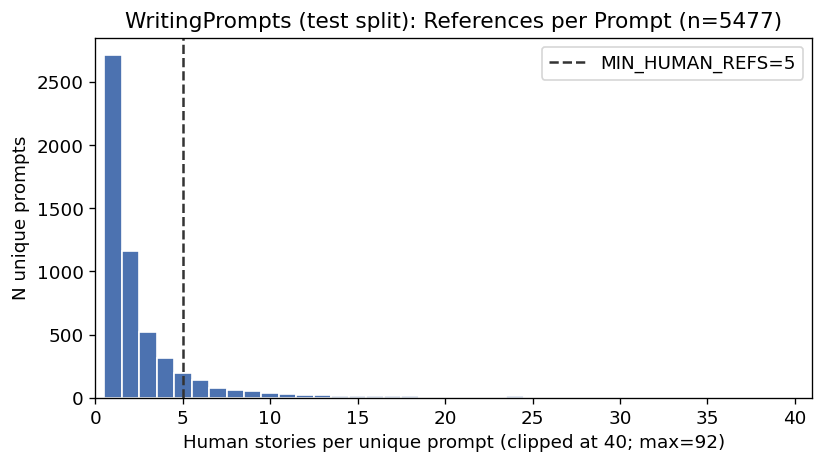

760 of 5477 unique prompts (13.9%) have >= 5 human references


In [4]:
# Group all human stories by their (cleaned) prompt text
stories_by_prompt = {}
for r in records:
    stories_by_prompt.setdefault(r['prompt'], []).append(r['story'])

n_unique = len(stories_by_prompt)
refs_per_prompt = np.array([len(v) for v in stories_by_prompt.values()])
print(f'{n_unique} unique prompts, {len(records)} total pairs '
      f'(avg {refs_per_prompt.mean():.2f} stories/prompt, max {refs_per_prompt.max()})')

fig, ax = plt.subplots(figsize=(7, 4))
bins = np.arange(1, 42) - 0.5
ax.hist(np.clip(refs_per_prompt, 1, 40), bins=bins, color='#4C72B0', edgecolor='white')
ax.axvline(MIN_HUMAN_REFS, color='#333333', linestyle='--', linewidth=1.5, label=f'MIN_HUMAN_REFS={MIN_HUMAN_REFS}')
ax.set_xlim(0, 41)
ax.set_xlabel('Human stories per unique prompt (clipped at 40; max=%d)' % refs_per_prompt.max())
ax.set_ylabel('N unique prompts')
ax.set_title(f'WritingPrompts (test split): References per Prompt (n={n_unique})')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'writingprompts_refs_per_prompt.png', dpi=300, bbox_inches='tight')
plt.show()

n_eligible_refs = int((refs_per_prompt >= MIN_HUMAN_REFS).sum())
print(f'{n_eligible_refs} of {n_unique} unique prompts ({100*n_eligible_refs/n_unique:.1f}%) '
      f'have >= {MIN_HUMAN_REFS} human references')

## Prompt Length Distribution

Prompt length (words): mean=21.6, median=20, min=1, max=62


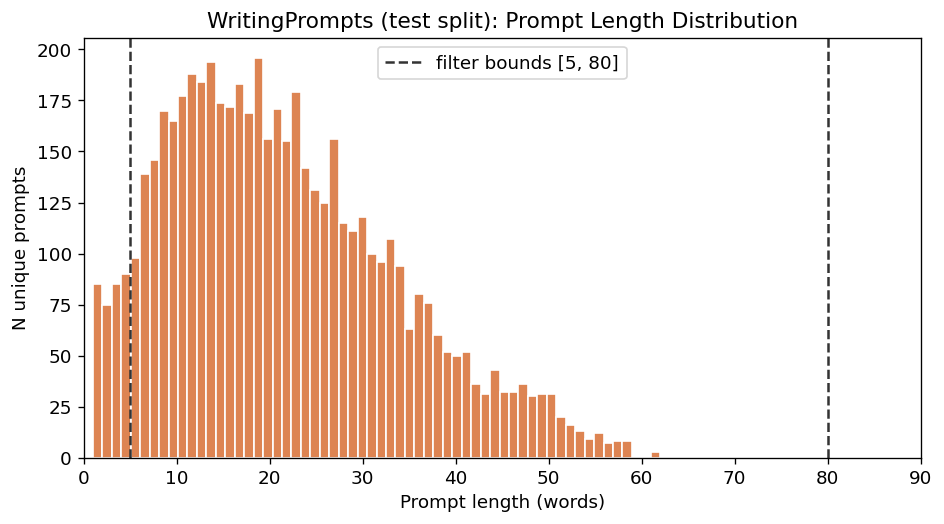

5232 of 5477 unique prompts (95.5%) fall within [5, 80] words (the upper bound is essentially a no-op here: longest prompt is 62 words)


In [5]:
unique_prompts = list(stories_by_prompt.keys())
prompt_word_counts = np.array([len(p.split()) for p in unique_prompts])

print(f'Prompt length (words): mean={prompt_word_counts.mean():.1f}, median={np.median(prompt_word_counts):.0f}, '
      f'min={prompt_word_counts.min()}, max={prompt_word_counts.max()}')

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(prompt_word_counts, bins=60, color='#DD8452', edgecolor='white')
ax.axvline(PROMPT_MIN_WORDS, color='#333333', linestyle='--', linewidth=1.5,
           label=f'filter bounds [{PROMPT_MIN_WORDS}, {PROMPT_MAX_WORDS}]')
ax.axvline(PROMPT_MAX_WORDS, color='#333333', linestyle='--', linewidth=1.5)
ax.set_xlim(0, 90)
ax.set_xlabel('Prompt length (words)')
ax.set_ylabel('N unique prompts')
ax.set_title('WritingPrompts (test split): Prompt Length Distribution')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'writingprompts_prompt_length.png', dpi=300, bbox_inches='tight')
plt.show()

in_range = (prompt_word_counts >= PROMPT_MIN_WORDS) & (prompt_word_counts <= PROMPT_MAX_WORDS)
print(f'{int(in_range.sum())} of {len(unique_prompts)} unique prompts ({100*in_range.mean():.1f}%) '
      f'fall within [{PROMPT_MIN_WORDS}, {PROMPT_MAX_WORDS}] words '
      f'(the upper bound is essentially a no-op here: longest prompt is {prompt_word_counts.max()} words)')

## Human Story Length Distribution

Story length (words): mean=553.7, median=458, min=88, max=2262


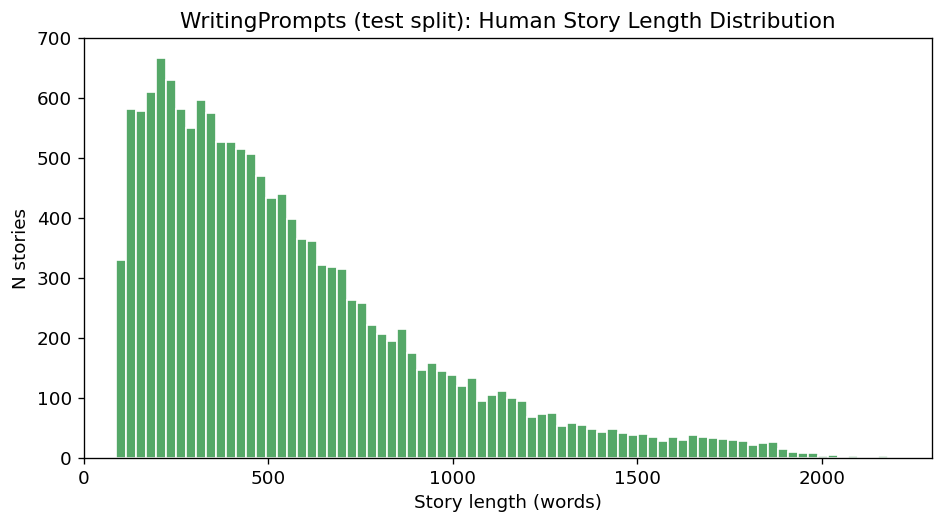

In [6]:
story_word_counts = np.array([len(r['story'].split()) for r in records])
print(f'Story length (words): mean={story_word_counts.mean():.1f}, median={np.median(story_word_counts):.0f}, '
      f'min={story_word_counts.min()}, max={story_word_counts.max()}')

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(story_word_counts, bins=80, color='#55A868', edgecolor='white')
ax.set_xlim(0, 2300)
ax.set_xlabel('Story length (words)')
ax.set_ylabel('N stories')
ax.set_title('WritingPrompts (test split): Human Story Length Distribution')
plt.tight_layout()
plt.savefig(FIG_DIR / 'writingprompts_story_length.png', dpi=300, bbox_inches='tight')
plt.show()

## Filtering Funnel

dedupe by prompt -> require >= 5 human references -> require prompt length in [5, 80] words -> sample 200 prompts (`seed=42`)

In [7]:
eligible_refs = [p for p in unique_prompts if len(stories_by_prompt[p]) >= MIN_HUMAN_REFS]
eligible_pool = [p for p in eligible_refs if PROMPT_MIN_WORDS <= len(p.split()) <= PROMPT_MAX_WORDS]

funnel = pd.DataFrame([
    {'stage': 'Raw prompt-story pairs (test split)', 'n': len(records)},
    {'stage': 'Unique prompts', 'n': n_unique},
    {'stage': f'>= {MIN_HUMAN_REFS} human references', 'n': len(eligible_refs)},
    {'stage': f'... and prompt length in [{PROMPT_MIN_WORDS}, {PROMPT_MAX_WORDS}] words (eligible pool)', 'n': len(eligible_pool)},
    {'stage': f'Sampled for generation (seed={SEED})', 'n': N_PROMPTS},
])
funnel['pct_of_unique_prompts'] = (100 * funnel['n'] / n_unique).round(1)
display(funnel)

,stage,n,pct_of_unique_prompts
0,Raw prompt-story pairs (test split),15137,276.4
1,Unique prompts,5477,100.0
2,>= 5 human references,760,13.9
3,"... and prompt length in [5, 80] words (eligib...",724,13.2
4,Sampled for generation (seed=42),200,3.7
